In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [172]:
plt.style.use("ggplot")

In [173]:
df = pd.read_csv("email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [175]:
df.isna().sum()


Category    0
Message     0
dtype: int64

In [176]:
df.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [177]:
df.tail(3)

,Category,Message
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [178]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [179]:
df = df.iloc[:-1]


In [180]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [181]:
df.head(3)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [182]:
df.shape

(5572, 2)

In [183]:
df.dtypes

Category    object
Message     object
dtype: object

In [184]:
df.isna().sum().sum()

np.int64(0)

In [185]:
df.duplicated().sum() /df.shape[0]

np.float64(0.07447954055994258)

In [186]:
df.drop_duplicates(inplace = True)

In [187]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [188]:
df['Category'].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [189]:
df['Category'].value_counts(normalize= True ) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

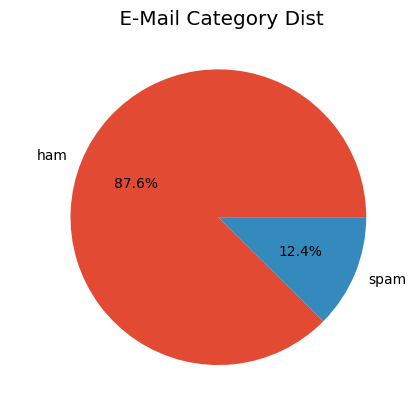

In [190]:
df['Category'].value_counts().plot(
    kind="pie",
    autopct = "%1.1f%%"
)
plt.ylabel(" ")

plt.title(" E-Mail Category Dist")

plt.show()

In [191]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [192]:
df["Message_Length"] = df["Message"].apply(len)

In [193]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [194]:
df["Message"][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [195]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

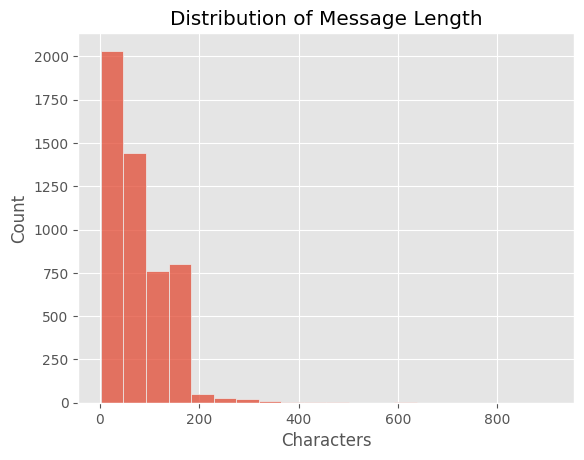

In [196]:
sns.histplot(df["Message_Length"], bins =20)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.show()

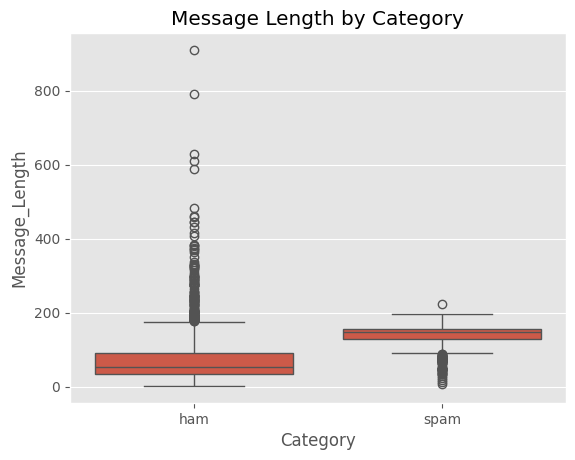

In [197]:
sns.boxplot(
    data = df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length by Category")
plt.show()

In [198]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

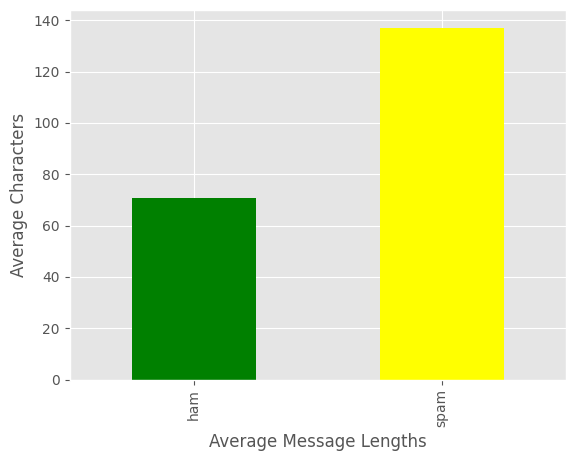

In [199]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind = "bar",
    color =["green","yellow"]

)

plt.ylabel("Average Characters")

plt.xlabel("Average Message Lengths")

plt.show()

In [200]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [201]:
df["Word_Count"] = df["Message"] .apply(lambda x: len(x.split()))

In [202]:
df.head(2)

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6


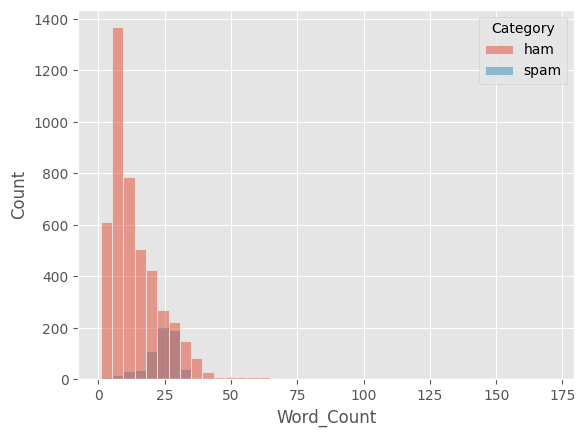

In [203]:
sns.histplot(
    data = df,
    x = "Word_Count",
    hue = "Category",
    bins = 40
)

plt.show()

In [204]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [205]:
df.nsmallest(10,"Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [206]:
df.nlargest(5,"Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125


In [207]:
df[df["Category"] == 'spam'].sample(5)

,Category,Message,Message_Length,Word_Count
3501,spam,Dorothy@kiefer.com (Bank of Granite issues Str...,156,23
4183,spam,Urgent! Please call 0906346330. Your ABTA comp...,143,23
3424,spam,Had your mobile 10 mths? Update to latest Oran...,157,28
1142,spam,I don't know u and u don't know me. Send CHAT ...,158,28
4823,spam,u r a winner U ave been specially selected 2 r...,151,29


In [208]:
df[df["Category"] == "ham"].sample(4,random_state=1)

,Category,Message,Message_Length,Word_Count
1258,ham,Am also doing in cbe only. But have to pay.,43,10
5180,ham,Babe! I fucking love you too !! You know? Fuck...,157,34
1296,ham,TELL HER I SAID EAT SHIT.,25,6
4886,ham,Poor girl can't go one day lmao,31,7


In [209]:
df['Category'] = df['Category'].map({
    "ham" : 0,
    "spam" : 1
})

In [210]:
df.head(3)

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28


In [211]:
import warnings
warnings.filterwarnings("ignore")

In [212]:
from sklearn.model_selection import train_test_split


In [213]:
X = df ["Message"]
y = df ["Category"]

In [214]:
X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y 
)

In [215]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words ="english",
    max_features = 5000,
    ngram_range = (1,2)
)

In [216]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [217]:
X_test_tfidf = tfidf.transform(X_test)

In [218]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [219]:
models = {
    "Naive Bayes" :(
        MultinomialNB(),
        {
            "alpha" : [0.1, 0.5, 1, 2, 5]
        }
    ),

    "LogisticRegression" :(
        LogisticRegression(
            class_weight= "balanced",
            max_iter= 1000
        ),
        {
            "C" : [0.01,0.1, 1, 10, 100]
        }
    ),
    "LinearSVM" : (
        LinearSVC(
            class_weight= "balanced"
        ),
            {
        "C" : [0.01,0.1 ,1,10]
        }

    ),

    "Random Forest" : (
        RandomForestClassifier(
            class_weight = "balanced"

        ),
        {
            "n_estimators" : [100, 200, 300],
            "max_depth" :[10,20, None],
            "min_samples_split" :[2,5, 10]

        }
    ),

    "DecisionTree" : (
        DecisionTreeClassifier(
            class_weight= "balanced"
        ),
        {
            "max_depth": [5, 10, 20, None],
            "min_samples_split" : [2,5, 10]
        }
    ),

    "Gradient Boosting" :(
        GradientBoostingClassifier(),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3,5]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3,5, 7, 9]
        }
    ) 
}

In [220]:
results = []

best_models = {}

for name, (model, params) in models.items():

    search = RandomizedSearchCV(
        estimator= model,
        param_distributions= params,
        n_iter= 10,
        cv= 5,
        scoring= "f1",
        n_jobs= -1
    )

    search.fit(X_train_tfidf, y_train)

    best_model = search.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test_tfidf)


    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    try:
        auc = roc_auc_score(y_test, best_model.decision_function(X_test_tfidf))
    except:
        try:
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf) [:,1]
            )
        except:
            auc =np.nan

    results.append({
        "Model": name,
        "Accuracy" :accuracy,
        "Precision" : precision,
        "Recall" :recall,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Best Params": search.best_params_

    })

In [221]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9777131782945736,
  'Precision': 0.9565217391304348,
  'Recall': 0.859375,
  'F1 Score': 0.9053497942386831,
  'ROC AUC': 0.9840120298672567,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.9806201550387597,
  'Precision': 0.9655172413793104,
  'Recall': 0.875,
  'F1 Score': 0.9180327868852459,
  'ROC AUC': 0.9882466814159293,
  'Best Params': {'C': 10}},
 {'Model': 'LinearSVM',
  'Accuracy': 0.9806201550387597,
  'Precision': 0.9736842105263158,
  'Recall': 0.8671875,
  'F1 Score': 0.9173553719008265,
  'ROC AUC': 0.9875553097345132,
  'Best Params': {'C': 1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9728682170542635,
  'Precision': 0.9545454545454546,
  'Recall': 0.8203125,
  'F1 Score': 0.8823529411764706,
  'ROC AUC': 0.976990286227876,
  'Best Params': {'n_estimators': 100,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'DecisionTree',
  'Accuracy': 0.9447674418604651,
  'Precision': 0

In [222]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by = "F1 Score",
    ascending= False
)

In [223]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
1,LogisticRegression,0.980620,0.965517,0.875000,0.918033,0.988247,{'C': 10}
2,LinearSVM,0.980620,0.973684,0.867188,0.917355,0.987555,{'C': 1}
0,Naive Bayes,0.977713,0.956522,0.859375,0.905350,0.984012,{'alpha': 0.1}
3,Random Forest,0.972868,0.954545,0.820312,0.882353,0.976990,"{'n_estimators': 100, 'min_samples_split': 10,..."
5,Gradient Boosting,0.968023,0.961165,0.773438,0.857143,0.955221,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,DecisionTree,0.944767,0.762963,0.804688,0.783270,0.867624,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.920543,1.000000,0.359375,0.528736,0.757104,{'n_neighbors': 3}


In [224]:
results_df.style.background_gradient(
    cmap= "Greens",
    subset=[ "Accuracy","Precision","Recall","F1 Score","ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
1,LogisticRegression,0.980620,0.965517,0.875000,0.918033,0.988247,{'C': 10}
2,LinearSVM,0.980620,0.973684,0.867188,0.917355,0.987555,{'C': 1}
0,Naive Bayes,0.977713,0.956522,0.859375,0.905350,0.984012,{'alpha': 0.1}
3,Random Forest,0.972868,0.954545,0.820312,0.882353,0.976990,"{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}"
5,Gradient Boosting,0.968023,0.961165,0.773438,0.857143,0.955221,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}"
4,DecisionTree,0.944767,0.762963,0.804688,0.783270,0.867624,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.920543,1.000000,0.359375,0.528736,0.757104,{'n_neighbors': 3}


In [225]:
results_df.reset_index(inplace= True)
results_df

,index,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,1,LogisticRegression,0.980620,0.965517,0.875000,0.918033,0.988247,{'C': 10}
1,2,LinearSVM,0.980620,0.973684,0.867188,0.917355,0.987555,{'C': 1}
2,0,Naive Bayes,0.977713,0.956522,0.859375,0.905350,0.984012,{'alpha': 0.1}
3,3,Random Forest,0.972868,0.954545,0.820312,0.882353,0.976990,"{'n_estimators': 100, 'min_samples_split': 10,..."
4,5,Gradient Boosting,0.968023,0.961165,0.773438,0.857143,0.955221,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,4,DecisionTree,0.944767,0.762963,0.804688,0.783270,0.867624,"{'min_samples_split': 5, 'max_depth': 20}"
6,6,KNN,0.920543,1.000000,0.359375,0.528736,0.757104,{'n_neighbors': 3}


In [226]:
results_df.drop(columns= "index", inplace=True)

In [227]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,LogisticRegression,0.980620,0.965517,0.875000,0.918033,0.988247,{'C': 10}
1,LinearSVM,0.980620,0.973684,0.867188,0.917355,0.987555,{'C': 1}
2,Naive Bayes,0.977713,0.956522,0.859375,0.905350,0.984012,{'alpha': 0.1}
3,Random Forest,0.972868,0.954545,0.820312,0.882353,0.976990,"{'n_estimators': 100, 'min_samples_split': 10,..."
4,Gradient Boosting,0.968023,0.961165,0.773438,0.857143,0.955221,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,DecisionTree,0.944767,0.762963,0.804688,0.783270,0.867624,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.920543,1.000000,0.359375,0.528736,0.757104,{'n_neighbors': 3}


In [228]:
best_model_name = results_df.iloc[0]["Model"]

In [229]:
best_model_name

'LogisticRegression'

In [230]:
best_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


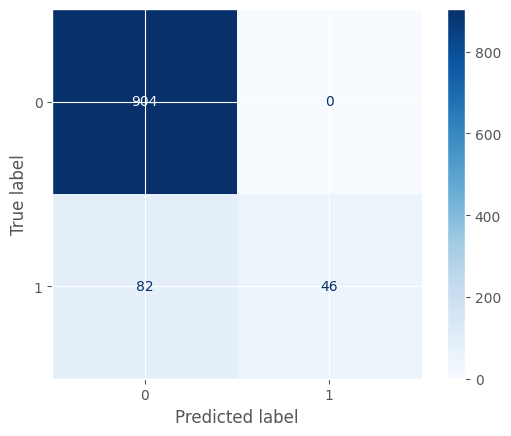

In [231]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap = "Blues"
)


In [232]:
emails = [
    "Congratulations! You won a free iPhone. Click here now.",

    "Hey, are we still meeting tomorrow at 10 AM",

    "Go until jurong point, crazy.. Available only",

    "Heey today whether is Good",

    "super offer only for you limited time period then grab"

    "URGENT! Claim your $1000 Walmart gift card today."
     
]

emails_vectorized = tfidf.transform(emails)

predictions = best_model.predict(emails_vectorized)

for email, prediction in zip(emails, predictions):

    label = "Spam" if prediction == 1 else "Ham"

    print(f"Emial : {email}")

    print(f"Prediction :{label}")

    print("_" * 70)

Emial : Congratulations! You won a free iPhone. Click here now.
Prediction :Ham
______________________________________________________________________
Emial : Hey, are we still meeting tomorrow at 10 AM
Prediction :Ham
______________________________________________________________________
Emial : Go until jurong point, crazy.. Available only
Prediction :Ham
______________________________________________________________________
Emial : Heey today whether is Good
Prediction :Ham
______________________________________________________________________
Emial : super offer only for you limited time period then grabURGENT! Claim your $1000 Walmart gift card today.
Prediction :Ham
______________________________________________________________________


In [233]:
import pickle 

with open("spam_classifier.pkl", "wb") as file:

    pickle.dump(best_model, file)

In [234]:
with open ("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Success")

Success


In [235]:
with open("spam_classifier.pkl","rb")as file:
    loaded_model = pickle.load(file)

with open("tfidf_vectorizer.pkl","rb")as file:

    loaded_vectorizer = pickle.load(file)

In [236]:
email = [
    "Congratulations! You won $1000. Click here"
]

email_vector = loaded_vectorizer.transform(email)

prediction = loaded_model.predict(email_vector)[0]

In [237]:
print("Spam" if prediction ==1 else "Ham")

Ham
